<a href="https://colab.research.google.com/github/fesaez/jupyter/blob/master/regressao_logistica%26gradiente_boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

“Análise comparativa de modelos de classificação

Objetivo: Prever a sobrevivência dos passageiros do Titanic usando dois algoritmos de Machine Learning e comparar seus resultados.

Modelos avaliados:

Regressão Logística (modelo linear e interpretável)
Gradient Boosting (ensemble de árvores, alta precisão)”

In [37]:
pip install kagglehub[pandas-datasets]

In [38]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [39]:
file_path = ""
file_path = "Titanic-Dataset.csv"

In [58]:
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "yasserh/titanic-dataset",
  file_path,
)

Using Colab cache for faster access to the 'titanic-dataset' dataset.


In [41]:
import os

for dirname, _, filenames in os.walk('/content'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
/content/.config/gce
/content/.config/active_config
/content/.config/default_configs.db
/content/.config/.last_update_check.json
/content/.config/.last_survey_prompt.yaml
/content/.config/.last_opt_in_prompt.yaml
/content/.config/config_sentinel
/content/.config/logs/2026.05.26/13.24.12.205210.log
/content/.config/logs/2026.05.26/13.24.58.593255.log
/content/.config/logs/2026.05.26/13.24.33.178031.log
/content/.config/logs/2026.05.26/13.25.00.641774.log
/content/.config/logs/2026.05.26/13.25.18.754663.log
/content/.config/logs/2026.05.26/13.25.17.583638.log
/content/.config/configurations/config_default
/content/sample_data/README.md
/content/sample_data/anscombe.json
/content/sample_data/california_housing_train.csv
/content/sample_data/mnist_test.csv
/content/sample_data/mnist_train_small.csv
/content/sample_data/california_housing_test.csv


In [42]:
# Carregamos todas as ferramentas necessárias para análise: pamdas e numpy,
#para manipulação de dados, matplotilib e seaborn para visualização,
# scikit-learn para os modelos de machine learning.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [43]:
# Modelos de Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

In [56]:
# Ferramentas de pré processamento e avaliação
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve,
                             precision_score, recall_score, f1_score)
from sklearn.impute import SimpleImputer

In [55]:
# Estilo visual consistente para todos os gráficos
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0']
sns.set_palette(PALETTE)

In [59]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Re-load df to ensure it is a DataFrame, in case it was overwritten or not properly assigned.
# file_path is available from previous cells.
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "yasserh/titanic-dataset",
  file_path,
)

print("EXPLORACIÓN INICIAL DEL DATASET")
print(f"\nDimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"\nColumnas disponibles:\n{list(df.columns)}")
print(f"\nPrimeras 5 filas:")
df.head()

Using Colab cache for faster access to the 'titanic-dataset' dataset.
EXPLORACIÓN INICIAL DEL DATASET

Dimensiones: 891 filas × 12 columnas

Columnas disponibles:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Primeras 5 filas:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [60]:
print("TIPOS DE DADOS E VALORES NULOS")

# ResuMO de tipos e valores nulos
info_df = pd.DataFrame({
    'Tipo': df.dtypes,
    'Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().sum() / len(df) * 100).round(2),
    'Únicos': df.nunique()
})
print(info_df)

print(f"\nEstadísticas descriptivas:")
df.describe()

TIPOS DE DADOS E VALORES NULOS
                Tipo  Nulos  % Nulos  Únicos
PassengerId    int64      0     0.00     891
Survived       int64      0     0.00       2
Pclass         int64      0     0.00       3
Name          object      0     0.00     891
Sex           object      0     0.00       2
Age          float64    177    19.87      88
SibSp          int64      0     0.00       7
Parch          int64      0     0.00       7
Ticket        object      0     0.00     681
Fare         float64      0     0.00     248
Cabin         object    687    77.10     147
Embarked      object      2     0.22       3

Estadísticas descriptivas:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [64]:
print("ESTATÍSTICAS DE SOBREVIVÊNCIA")

# Sobrevivência geral
total = len(df)
sobreviveram = df['Survived'].sum()
faleceram = total - sobreviveram

print(f"\nTotal de passageiros: {total}")
print(f"Sobreviveram: {sobreviveram} ({sobreviveram/total*100:.1f}%)")
print(f"Faleceram: {faleceram} ({faleceram/total*100:.1f}%)")

ESTATÍSTICAS DE SOBREVIVÊNCIA

Total de passageiros: 891
Sobreviveram: 342 (38.4%)
Faleceram: 549 (61.6%)


In [65]:
# Por gênero
print("\n--- Por Gênero ---")

gen = df.groupby('Sex')['Survived'].agg(['sum', 'count', 'mean'])

gen.columns = ['Sobreviveram', 'Total', 'Taxa']

gen['Taxa'] = (gen['Taxa'] * 100).round(1)

print(gen)


--- Por Gênero ---
        Sobreviveram  Total  Taxa
Sex                              
female           233    314  74.2
male             109    577  18.9


In [66]:
# Por classe
print("\n--- Por Classe (Pclass) ---")

classe = df.groupby('Pclass')['Survived'].agg(['sum', 'count', 'mean'])

classe.columns = ['Sobreviveram', 'Total', 'Taxa']

classe['Taxa'] = (classe['Taxa'] * 100).round(1)

print(classe)


--- Por Classe (Pclass) ---
        Sobreviveram  Total  Taxa
Pclass                           
1                136    216  63.0
2                 87    184  47.3
3                119    491  24.2


In [67]:
# Mulheres e crianças
mulheres_criancas = df[(df['Sex'] == 'female') | (df['Age'] <= 12)]

taxa_mc = mulheres_criancas['Survived'].mean() * 100

homens_adultos = df[(df['Sex'] == 'male') & (df['Age'] > 12)]

taxa_h = homens_adultos['Survived'].mean() * 100

print(f"\nMulheres e crianças: {taxa_mc:.1f}% de sobrevivência")

print(f"Homens adultos: {taxa_h:.1f}% de sobrevivência")


Mulheres e crianças: 72.4% de sobrevivência
Homens adultos: 17.3% de sobrevivência


In [68]:
# Classe 1 vs resto
classe1 = df[df['Pclass'] == 1]['Survived'].mean() * 100
resto = df[df['Pclass'] != 1]['Survived'].mean() * 100

print(f"\nPrimeira classe: {classe1:.1f}% de sobrevivência")
print(f"Segunda e terceira classe: {resto:.1f}% de sobrevivência")


Primeira classe: 63.0% de sobrevivência
Segunda e terceira classe: 30.5% de sobrevivência


In [78]:
# Gráficos de exploração -Identificar padrões de distribuição, correlação visual e desequilibrios na variável alvo (Survived)."
#figsize=(18, 14) → define o tamanho da figura.
#GridSpec(3, 3) → cria uma grade de 3 linhas por 3 colunas.
#hspace=0.45 → espaço vertical entre os gráficos.
#wspace=0.35 → espaço horizontal entre os gráficos.

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 3)


fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

<Figure size 1800x1400 with 0 Axes>

<Figure size 1800x1400 with 0 Axes>

(0.0, 647.8199999999999)

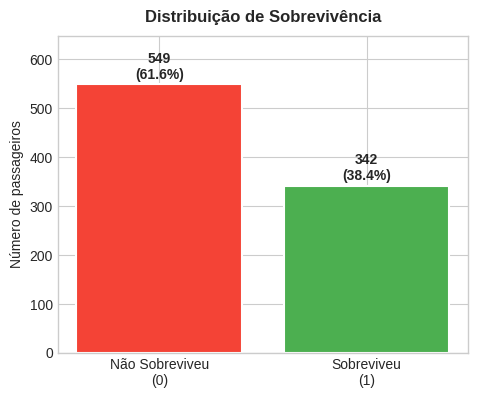

In [81]:
# ── Gráfico 1: Distribuição da variável alvo

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 3)

ax1 = fig.add_subplot(gs[0, 0])

counts = df['Survived'].value_counts()

bars = ax1.bar(
    ['Não Sobreviveu\n(0)', 'Sobreviveu\n(1)'],
    counts.values,
    color=['#F44336', '#4CAF50'],
    edgecolor='white',
    linewidth=1.5
)

for bar, val in zip(bars, counts.values):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        f'{val}\n({val/total*100:.1f}%)',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

ax1.set_title('Distribuição de Sobrevivência', fontweight='bold', pad=10)
ax1.set_ylabel('Número de passageiros')
ax1.set_ylim(0, max(counts.values) * 1.18)

[Text(0, 0, 'Mulher'), Text(1, 0, 'Homem')]

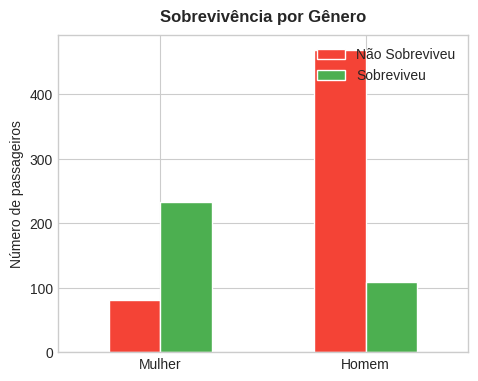

In [82]:
# ── Gráfico 2: Sobrevivência por gênero
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 3)

ax2 = fig.add_subplot(gs[0, 1])

gen_data = df.groupby(['Sex', 'Survived']).size().unstack()

gen_data.plot(
    kind='bar',
    ax=ax2,
    color=['#F44336', '#4CAF50'],
    edgecolor='white',
    rot=0
)

ax2.set_title('Sobrevivência por Gênero', fontweight='bold', pad=10)
ax2.set_xlabel('')
ax2.set_ylabel('Número de passageiros')

ax2.legend(
    ['Não Sobreviveu', 'Sobreviveu'],
    loc='upper right'
)

ax2.set_xticklabels(['Mulher', 'Homem'])

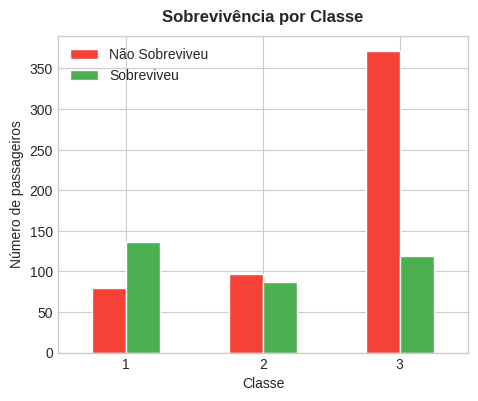

In [83]:
# ── Gráfico 3: Sobrevivência por classe
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 3)

ax3 = fig.add_subplot(gs[0, 2])

clase_data = df.groupby(['Pclass', 'Survived']).size().unstack()

clase_data.plot(
    kind='bar',
    ax=ax3,
    color=['#F44336', '#4CAF50'],
    edgecolor='white',
    rot=0
)

ax3.set_title('Sobrevivência por Classe', fontweight='bold', pad=10)

ax3.set_xlabel('Classe')
ax3.set_ylabel('Número de passageiros')

ax3.legend(['Não Sobreviveu', 'Sobreviveu'])

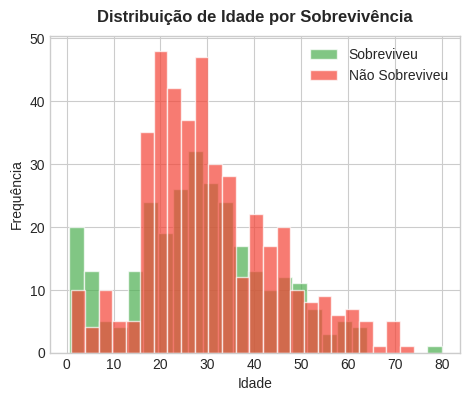

In [84]:
# ── Gráfico 4: Distribuição de idade
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 3)

ax4 = fig.add_subplot(gs[1, 0])

df[df['Survived'] == 1]['Age'].dropna().plot(
    kind='hist',
    ax=ax4,
    bins=25,
    alpha=0.7,
    color='#4CAF50',
    label='Sobreviveu',
    edgecolor='white'
)

df[df['Survived'] == 0]['Age'].dropna().plot(
    kind='hist',
    ax=ax4,
    bins=25,
    alpha=0.7,
    color='#F44336',
    label='Não Sobreviveu',
    edgecolor='white'
)

ax4.set_title(
    'Distribuição de Idade por Sobrevivência',
    fontweight='bold',
    pad=10
)

ax4.set_xlabel('Idade')
ax4.set_ylabel('Frequência')

ax4.legend()

Text(0, 0.5, 'Tarifa (£)')

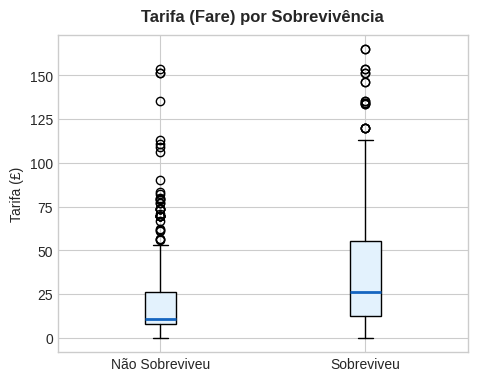

In [85]:
# ── Gráfico 5: Tarifa vs sobrevivência (boxplot)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 3)

ax5 = fig.add_subplot(gs[1, 1])

# Removemos outliers extremos para melhor visualização
df_fare = df[df['Fare'] < 200]

ax5.boxplot(
    [
        df_fare[df_fare['Survived'] == 0]['Fare'].dropna(),
        df_fare[df_fare['Survived'] == 1]['Fare'].dropna()
    ],
    labels=['Não Sobreviveu', 'Sobreviveu'],
    patch_artist=True,
    boxprops=dict(facecolor='#E3F2FD'),
    medianprops=dict(color='#1565C0', linewidth=2)
)

ax5.set_title(
    'Tarifa (Fare) por Sobrevivência',
    fontweight='bold',
    pad=10
)

ax5.set_ylabel('Tarifa (£)')

Text(1185.2892156862745, 0.5, '')

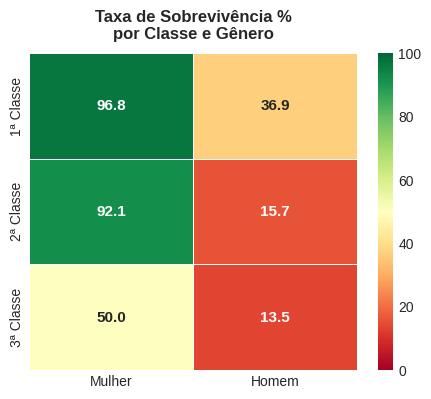

In [86]:
# ── Gráfico 6: Taxa de sobrevivência por classe e gênero (heatmap)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 3)


ax6 = fig.add_subplot(gs[1, 2])

pivot = df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack()

pivot.columns = ['Mulher', 'Homem']
pivot.index = ['1ª Classe', '2ª Classe', '3ª Classe']

sns.heatmap(
    pivot * 100,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    ax=ax6,
    vmin=0,
    vmax=100,
    linewidths=0.5,
    annot_kws={'size': 11, 'weight': 'bold'}
)

ax6.set_title(
    'Taxa de Sobrevivência %\npor Classe e Gênero',
    fontweight='bold',
    pad=10
)

ax6.set_xlabel('')
ax6.set_ylabel('')

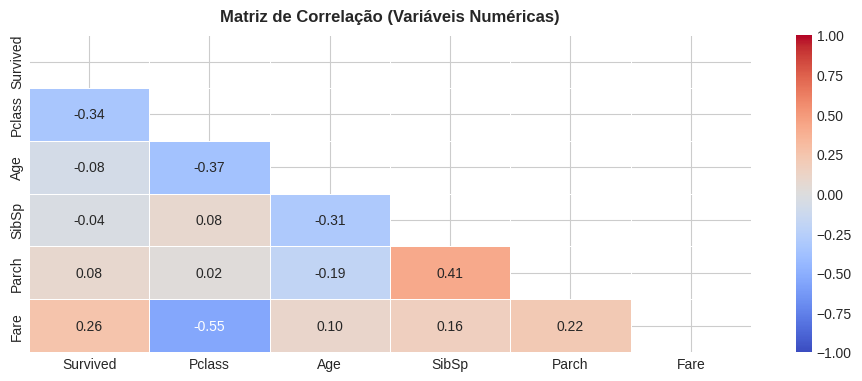

In [87]:
# ── Gráfico 7: Correlação de variáveis numéricas
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 3)

ax7 = fig.add_subplot(gs[2, :2])

num_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

corr = df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    ax=ax7,
    mask=mask,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    annot_kws={'size': 10}
)

ax7.set_title(
    'Matriz de Correlação (Variáveis Numéricas)',
    fontweight='bold',
    pad=10
)
plt.show()

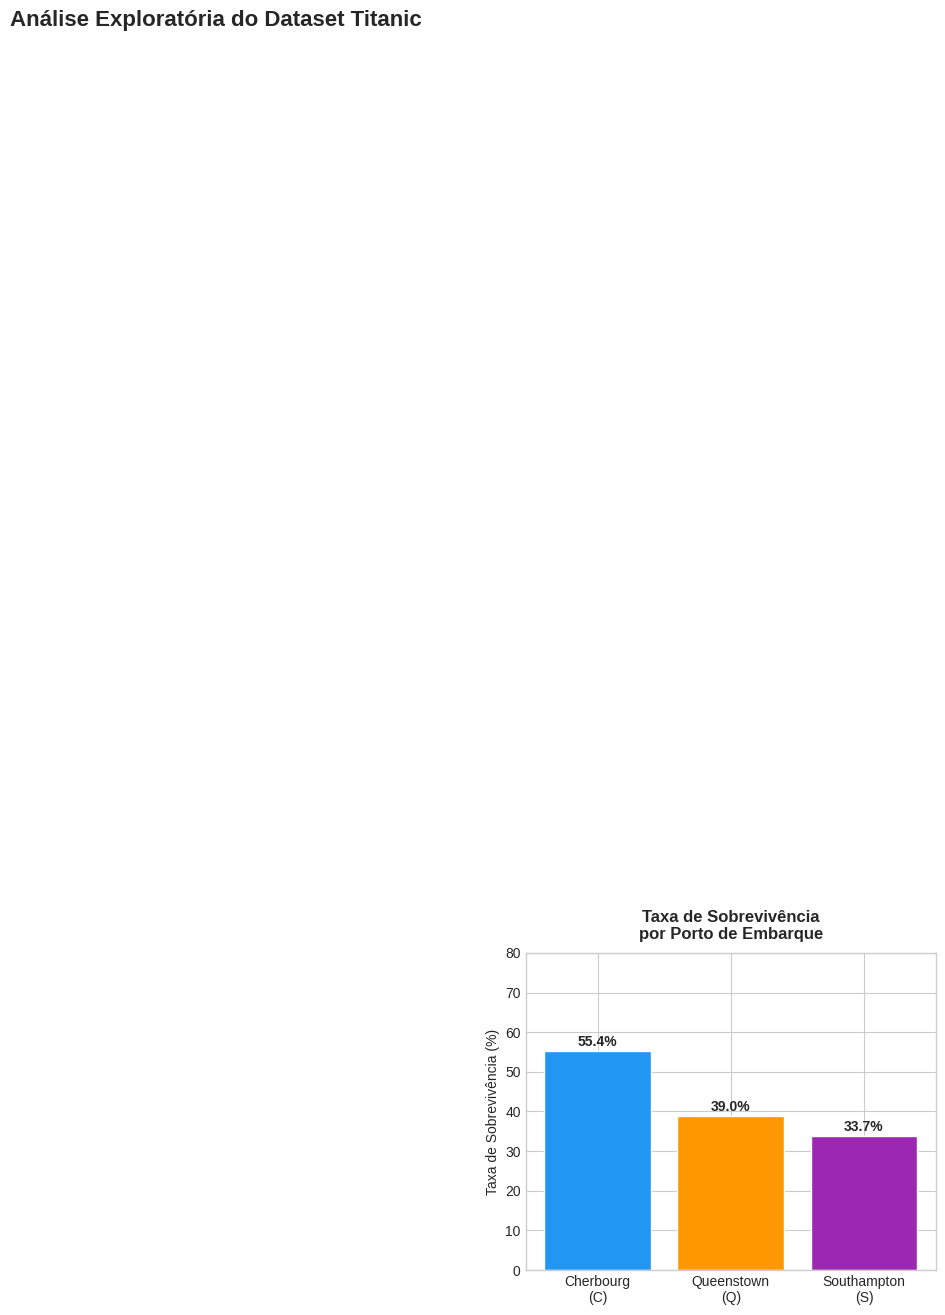

In [89]:
# ── Gráfico 8: Embarque
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 3)

ax8 = fig.add_subplot(gs[2, 2])

emb = df.groupby('Embarked')['Survived'].mean() * 100

emb.index = [
    'Cherbourg\n(C)',
    'Queenstown\n(Q)',
    'Southampton\n(S)'
]

bars8 = ax8.bar(
    emb.index,
    emb.values,
    color=['#2196F3', '#FF9800', '#9C27B0'],
    edgecolor='white'
)

for bar, val in zip(bars8, emb.values):
    ax8.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{val:.1f}%',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

ax8.set_title(
    'Taxa de Sobrevivência\npor Porto de Embarque',
    fontweight='bold',
    pad=10
)

ax8.set_ylabel('Taxa de Sobrevivência (%)')
ax8.set_ylim(0, 80)

fig.suptitle(
    'Análise Exploratória do Dataset Titanic',
    fontsize=16,
    fontweight='bold',
    y=1.01
)

plt.savefig(
    'exploracao_titanic.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()


In [90]:
#Limpeza e engenharia de características (ou feature engineering). Tratamos os valores nulos, eliminamos colunas irrelevantes e criamos novas variáveis que podem melhorar a capacidade preditiva dos modelos.
df_clean = df.copy()

In [91]:
# 1. Extrair o título do nome (Mr, Mrs, Miss, etc.)
# O título é um indicador de gênero, idade e status social
df_clean['Title'] = df_clean['Name'].str.extract(
    r' ([A-Za-z]+)\.',
    expand=False
)

In [92]:
# Agrupamos títulos raros em categorias mais gerais
titulo_map = {
    'Mr': 'Mr',
    'Miss': 'Miss',
    'Mrs': 'Mrs',
    'Master': 'Master',
    'Dr': 'Raro',
    'Rev': 'Raro',
    'Col': 'Raro',
    'Major': 'Raro',
    'Mlle': 'Miss',
    'Countess': 'Mrs',
    'Ms': 'Miss',
    'Lady': 'Mrs',
    'Jonkheer': 'Raro',
    'Don': 'Raro',
    'Dona': 'Raro',
    'Mme': 'Mrs',
    'Capt': 'Raro',
    'Sir': 'Raro'
}

df_clean['Title'] = df_clean['Title'].map(titulo_map).fillna('Raro')

In [93]:
# 2. Preencher Age com a mediana por título
# A mediana é mais robusta que a média diante de outliers extremos

for titulo in df_clean['Title'].unique():
    mediana = df_clean[df_clean['Title'] == titulo]['Age'].median()

    df_clean.loc[
        (df_clean['Age'].isnull()) &
        (df_clean['Title'] == titulo),
        'Age'
    ] = mediana

In [94]:
# 3. Preencher Embarked com a moda (valor mais frequente)
df_clean['Embarked'] = df_clean['Embarked'].fillna(
    df_clean['Embarked'].mode()[0]
)

In [95]:
# 4. Preencher Fare com a mediana por classe (1 valor ausente)
df_clean['Fare'] = df_clean.groupby('Pclass')['Fare'].transform(
    lambda x: x.fillna(x.median())
)

In [96]:
# 5. Criar novas variáveis derivadas

# Tamanho total da família
df_clean['FamilySize'] = (
    df_clean['SibSp'] + df_clean['Parch'] + 1
)

# Viajava sozinho?
df_clean['IsAlone'] = (
    df_clean['FamilySize'] == 1
).astype(int)

# Faixas etárias
df_clean['AgeGroup'] = pd.cut(
    df_clean['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=[
        'Criança',
        'Adolescente',
        'Adulto Jovem',
        'Adulto',
        'Idoso'
    ]
)

# Quartis da tarifa
df_clean['FareBand'] = pd.qcut(
    df_clean['Fare'],
    4,
    labels=[0, 1, 2, 3]
)

In [97]:
# 6. Remover colunas não relevantes para o modelo
# Name, Ticket e Cabin têm alta cardinalidade ou muitos valores nulos (77%)

cols_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df_clean = df_clean.drop(columns=cols_drop)

In [98]:
# 7. Codificação de variáveis categóricas (One-Hot Encoding)

df_clean = pd.get_dummies(
    df_clean,
    columns=['Sex', 'Embarked', 'Title', 'AgeGroup'],
    drop_first=False
)

In [99]:
df_clean['FareBand'] = pd.qcut(df_clean['Fare'], 4, labels=[0, 1, 2, 3])

In [100]:
# Verificação final
print("LIMPEZA E ENGENHARIA DE ATRIBUTOS CONCLUÍDA")
print(f"\nDimensões finais: {df_clean.shape}")
print(f"\nValores nulos restantes: {df_clean.isnull().sum().sum()}")
print(f"\nColunas do dataset limpo:")

for col in df_clean.columns:
    print(f"   - {col} ({df_clean[col].dtype})")

LIMPEZA E ENGENHARIA DE ATRIBUTOS CONCLUÍDA

Dimensões finais: (891, 24)

Valores nulos restantes: 0

Colunas do dataset limpo:
   - Survived (int64)
   - Pclass (int64)
   - Age (float64)
   - SibSp (int64)
   - Parch (int64)
   - Fare (float64)
   - FamilySize (int64)
   - IsAlone (int64)
   - FareBand (category)
   - Sex_female (bool)
   - Sex_male (bool)
   - Embarked_C (bool)
   - Embarked_Q (bool)
   - Embarked_S (bool)
   - Title_Master (bool)
   - Title_Miss (bool)
   - Title_Mr (bool)
   - Title_Mrs (bool)
   - Title_Raro (bool)
   - AgeGroup_Criança (bool)
   - AgeGroup_Adolescente (bool)
   - AgeGroup_Adulto Jovem (bool)
   - AgeGroup_Adulto (bool)
   - AgeGroup_Idoso (bool)


In [101]:
#Preparação para o modeloSeparação em conjuntos de treinamento e teste. Dividimos os dados em 80% para treinamento e 20% para teste.
# Variável alvo e características (features)
TARGET = 'Survived'

X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

In [102]:
# Divisão: garante proporção das classes no treino e teste

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [103]:
# Escalonamento de características (necessário para Regressão Logística)
# Gradient Boosting não exige, mas aplicamos em ambos para comparação justa

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [104]:
print("DADOS PREPARADOS PARA MODELAGEM")

print(f"\nConjunto de treinamento: {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Conjunto de teste:        {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.0f}%)")

print(f"\nDistribuição no treinamento:")
print(f"   Sobreviveu (1): {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"   Morreu     (0): {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%)")

print(f"\nDistribuição no teste:")
print(f"   Sobreviveu (1): {y_test.sum()} ({y_test.mean()*100:.1f}%)")
print(f"   Morreu     (0): {(y_test==0).sum()} ({(y_test==0).mean()*100:.1f}%)")

print(f"\nNúmero de características: {X_train.shape[1]}")

DADOS PREPARADOS PARA MODELAGEM

Conjunto de treinamento: 712 amostras (80%)
Conjunto de teste:        179 amostras (20%)

Distribuição no treinamento:
   Sobreviveu (1): 273 (38.3%)
   Morreu     (0): 439 (61.7%)

Distribuição no teste:
   Sobreviveu (1): 69 (38.5%)
   Morreu     (0): 110 (61.5%)

Número de características: 23


In [105]:
#Modelo 1: Regressão Logística
# Hiperparâmetros usados:\(C = 0.1\): regularização mais forte
#(penaliza coeficientes grandes)solver='lbfgs': otimizador
#eficiente para conjuntos de dados (datasets) médiosmax_iter=1000:
#iterações suficientes para convergir

print("MODELO 1: REGRESSÃO LOGÍSTICA")


MODELO 1: REGRESSÃO LOGÍSTICA


In [107]:
# Previsões
# Instantiate and train the Logistic Regression model (lr)
# Note: Ideally, model instantiation and training would be in a separate cell before this one.
lr = LogisticRegression(C=0.1, solver='lbfgs', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]  # Probabilidade da classe positiva

# Métricas principais
acc_lr  = accuracy_score(y_test, y_pred_lr)
auc_lr  = roc_auc_score(y_test, y_prob_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr  = recall_score(y_test, y_pred_lr)
f1_lr   = f1_score(y_test, y_pred_lr)

In [108]:
# Validação cruzada (5 folds) — evita overfitting em uma única divisão
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_lr = cross_val_score(
    lr,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring='accuracy'
)

In [111]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_lr = cross_val_score(
    lr,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring='accuracy'
)

In [112]:
print(f"\nResultados no conjunto de teste:")
print(f"   Accuracy  : {acc_lr:.4f}  ({acc_lr*100:.2f}%)")
print(f"   AUC-ROC   : {auc_lr:.4f}")
print(f"   Precision : {prec_lr:.4f}")
print(f"   Recall    : {rec_lr:.4f}")
print(f"   F1-Score  : {f1_lr:.4f}")

print(f"\nValidação Cruzada (5-fold):")
print(f"   Média   : {cv_scores_lr.mean():.4f}")
print(f"   Desvio  : {cv_scores_lr.std():.4f}")
print(f"   Scores  : {[f'{s:.4f}' for s in cv_scores_lr]}")

print(f"\nRelatório de Classificação:")
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=['Não Sobreviveu', 'Sobreviveu']
))


Resultados no conjunto de teste:
   Accuracy  : 0.8492  (84.92%)
   AUC-ROC   : 0.8748
   Precision : 0.8387
   Recall    : 0.7536
   F1-Score  : 0.7939

Validação Cruzada (5-fold):
   Média   : 0.8188
   Desvio  : 0.0272
   Scores  : ['0.8252', '0.8112', '0.8592', '0.7746', '0.8239']

Relatório de Classificação:
                precision    recall  f1-score   support

Não Sobreviveu       0.85      0.91      0.88       110
    Sobreviveu       0.84      0.75      0.79        69

      accuracy                           0.85       179
     macro avg       0.85      0.83      0.84       179
  weighted avg       0.85      0.85      0.85       179



Modelo 2: Gradient Boosting
Hiperparâmetros usados:

n_estimators=200: quantidade de árvores (mais árvores = modelo mais potente, porém mais lento)
learning_rate=0.05: quanto cada árvore aprende (passo pequeno = mais estável)
max_depth=4: profundidade máxima de cada árvore
subsample=0.8: fração dos dados usada por árvore (regularização estocástica)
min_samples_leaf=20: número mínimo de amostras em cada folha (evita overfitting)

In [114]:
print("MODELO 2: GRADIENT BOOSTING")

MODELO 2: GRADIENT BOOSTING


In [116]:
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    min_samples_leaf=20,
    random_state=42
)

In [126]:
gb.fit(X_train_scaled, y_train)

y_pred_gb = gb.predict(X_test_scaled)
y_prob_gb = gb.predict_proba(X_test_scaled)[:, 1]

In [118]:
# Métricas principais
acc_gb  = accuracy_score(y_test, y_pred_gb)
auc_gb  = roc_auc_score(y_test, y_prob_gb)
prec_gb = precision_score(y_test, y_pred_gb)
rec_gb  = recall_score(y_test, y_pred_gb)
f1_gb   = f1_score(y_test, y_pred_gb)

In [119]:
# Validação cruzada
cv_scores_gb = cross_val_score(
    gb,
    X_train,
    y_train,
    cv=cv,
    scoring='accuracy'
)

In [120]:
print(f"\nResultados no conjunto de teste:")
print(f"   Accuracy  : {acc_gb:.4f}  ({acc_gb*100:.2f}%)")
print(f"   AUC-ROC   : {auc_gb:.4f}")
print(f"   Precision : {prec_gb:.4f}")
print(f"   Recall    : {rec_gb:.4f}")
print(f"   F1-Score  : {f1_gb:.4f}")

print(f"\nValidação Cruzada (5-fold):")
print(f"   Média   : {cv_scores_gb.mean():.4f}")
print(f"   Desvio  : {cv_scores_gb.std():.4f}")
print(f"   Scores  : {[f'{s:.4f}' for s in cv_scores_gb]}")

print(f"\nRelatório de Classificação:")
print(classification_report(
    y_test,
    y_pred_gb,
    target_names=['Não Sobreviveu', 'Sobreviveu']
))


Resultados no conjunto de teste:
   Accuracy  : 0.8212  (82.12%)
   AUC-ROC   : 0.8408
   Precision : 0.8033
   Recall    : 0.7101
   F1-Score  : 0.7538

Validação Cruzada (5-fold):
   Média   : 0.8329
   Desvio  : 0.0149
   Scores  : ['0.8531', '0.8112', '0.8451', '0.8239', '0.8310']

Relatório de Classificação:
                precision    recall  f1-score   support

Não Sobreviveu       0.83      0.89      0.86       110
    Sobreviveu       0.80      0.71      0.75        69

      accuracy                           0.82       179
     macro avg       0.82      0.80      0.81       179
  weighted avg       0.82      0.82      0.82       179



Text(0.5, 1.01, 'Regressão Logística vs Gradient Boosting — Titanic')

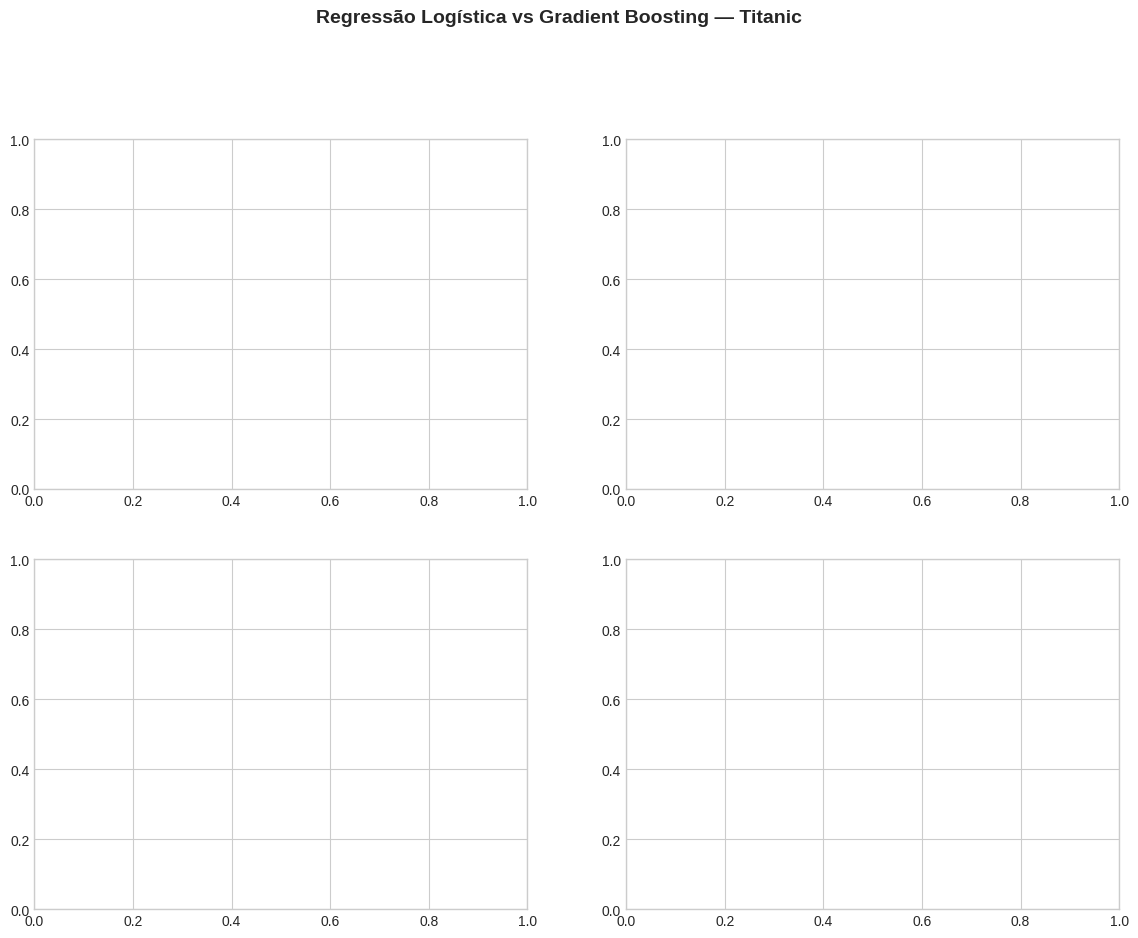

In [121]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Regressão Logística vs Gradient Boosting — Titanic', fontsize=14, fontweight='bold', y=1.01)

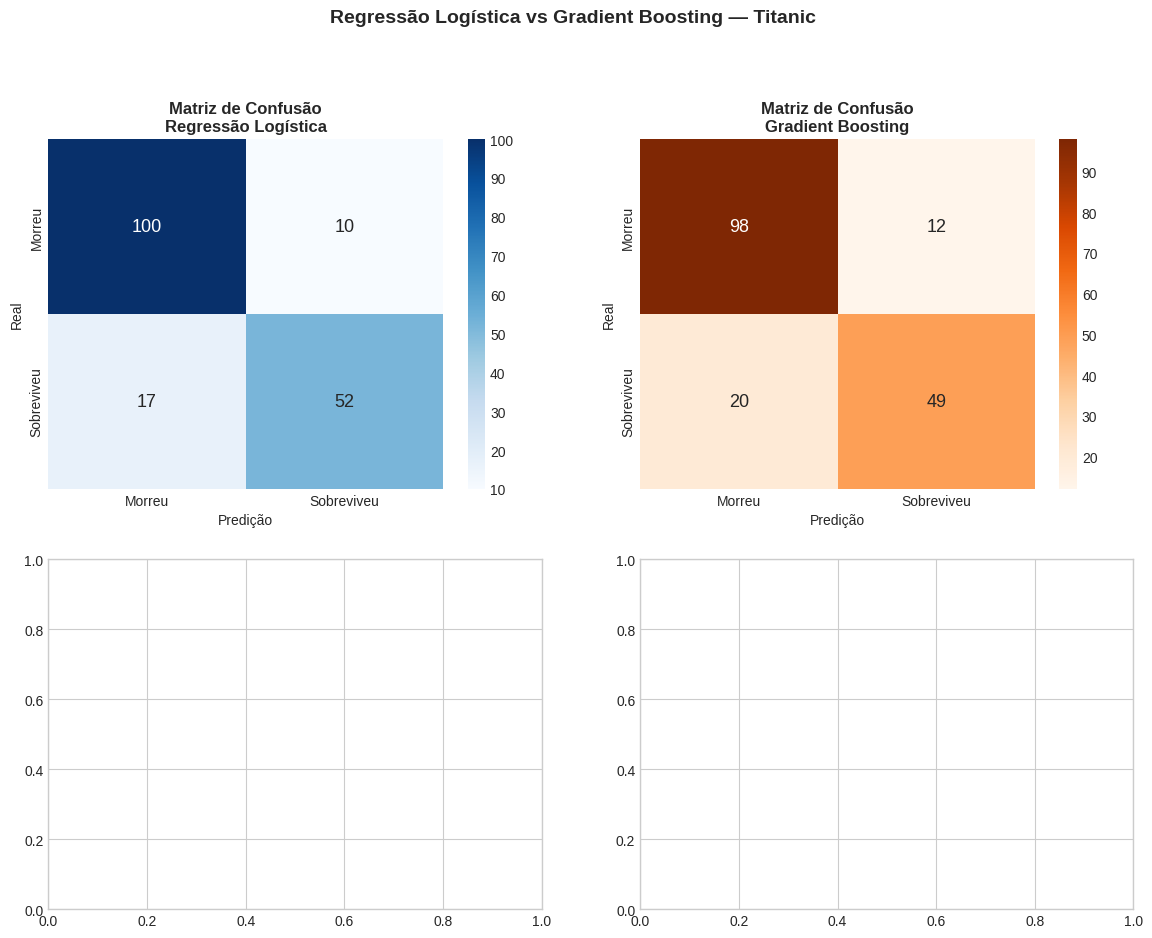

In [123]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Regressão Logística vs Gradient Boosting — Titanic', fontsize=14, fontweight='bold', y=1.01)

# 1. Matrizes de confusão (lado a lado)
for ax, cm, titulo, cmap in zip(
    [axes[0, 0], axes[0, 1]],
    [confusion_matrix(y_test, y_pred_lr), confusion_matrix(y_test, y_pred_gb)],
    ['Regressão Logística', 'Gradient Boosting'],
    ['Blues', 'Oranges']
):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Morreu', 'Sobreviveu'],
                yticklabels=['Morreu', 'Sobreviveu'],
                annot_kws={'size': 13})
    ax.set_title(f'Matriz de Confusão\n{titulo}', fontweight='bold')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predição')


In [127]:
# 2. Curvas ROC
ax3 = axes[1][1, 0]
for fpr, tpr, auc, label, color in [
    (*roc_curve(y_test, y_prob_lr)[:2], auc_lr, f'Reg. Logística (AUC={auc_lr:.3f})', '#2196F3'),
    (*roc_curve(y_test, y_prob_gb)[:2], auc_gb, f'Gradient Boosting (AUC={auc_gb:.3f})', '#FF9800'),
]:
    ax3.plot(fpr, tpr, lw=2, label=label, color=color)
ax3.plot([0, 1], [0, 1], 'k--', lw=1)
ax3.set_title('Curvas ROC', fontweight='bold')
ax3.set_xlabel('Taxa de Falsos Positivos')
ax3.set_ylabel('Taxa de Verdadeiros Positivos')
ax3.legend()

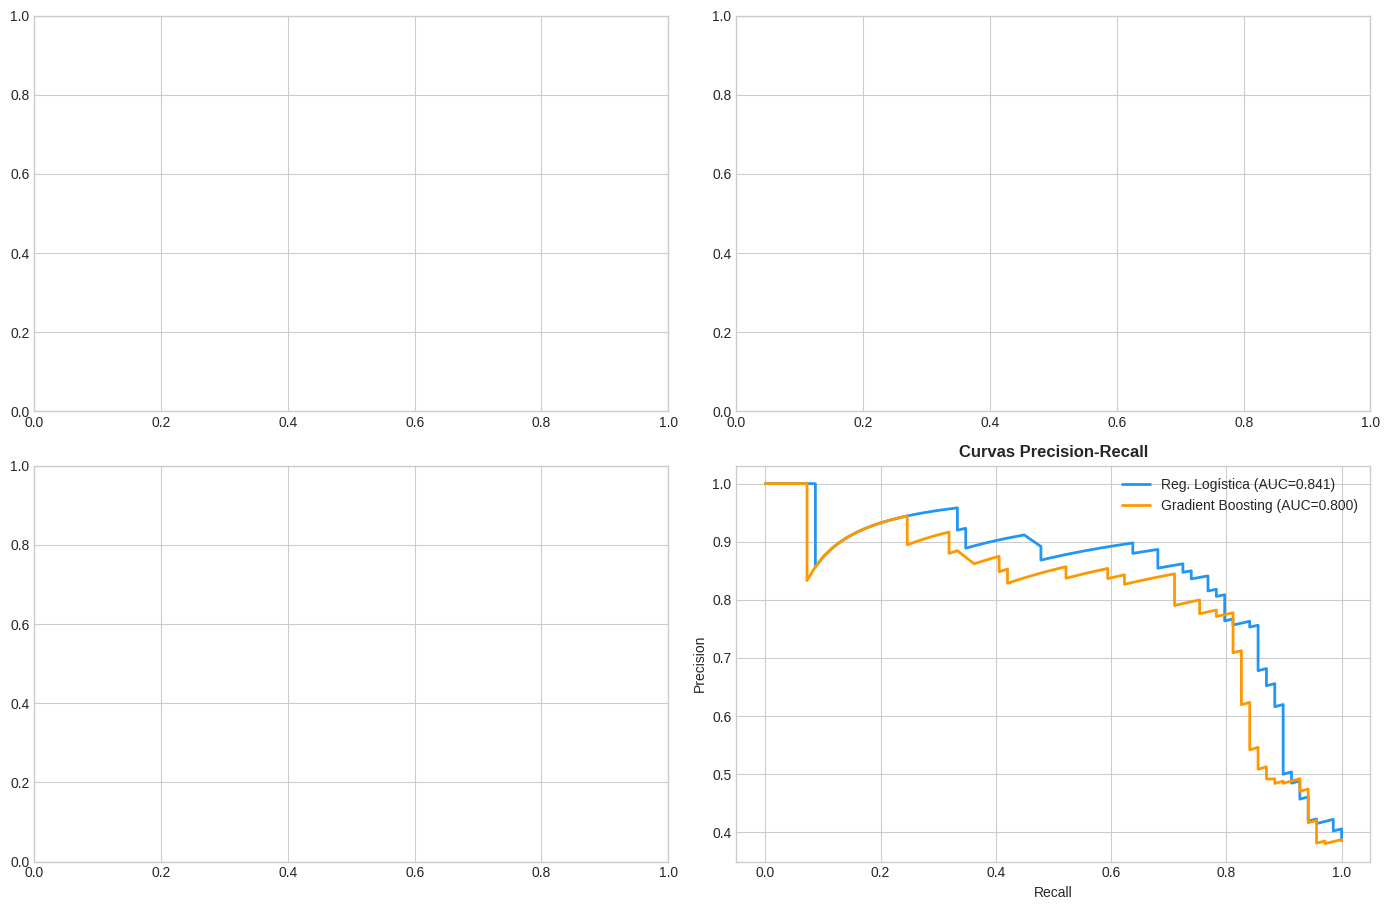

In [136]:
# 3. Curvas Precision-Recall
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))


ax4 = axes[1][1]

# Logistic Regression
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob_lr)
auc_precision_recall_lr = auc(recall_lr, precision_lr)
ax4.plot(recall_lr, precision_lr, lw=2, label=f'Reg. Logística (AUC={auc_precision_recall_lr:.3f})', color='#2196F3')

# Gradient Boosting
precision_gb, recall_gb, _ = precision_recall_curve(y_test, y_prob_gb)
auc_precision_recall_gb = auc(recall_gb, precision_gb)
ax4.plot(recall_gb, precision_gb, lw=2, label=f'Gradient Boosting (AUC={auc_precision_recall_gb:.3f})', color='#FF9800')

ax4.set_title('Curvas Precision-Recall', fontweight='bold')
ax4.set_xlabel('Recall')
ax4.set_ylabel('Precision')
ax4.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

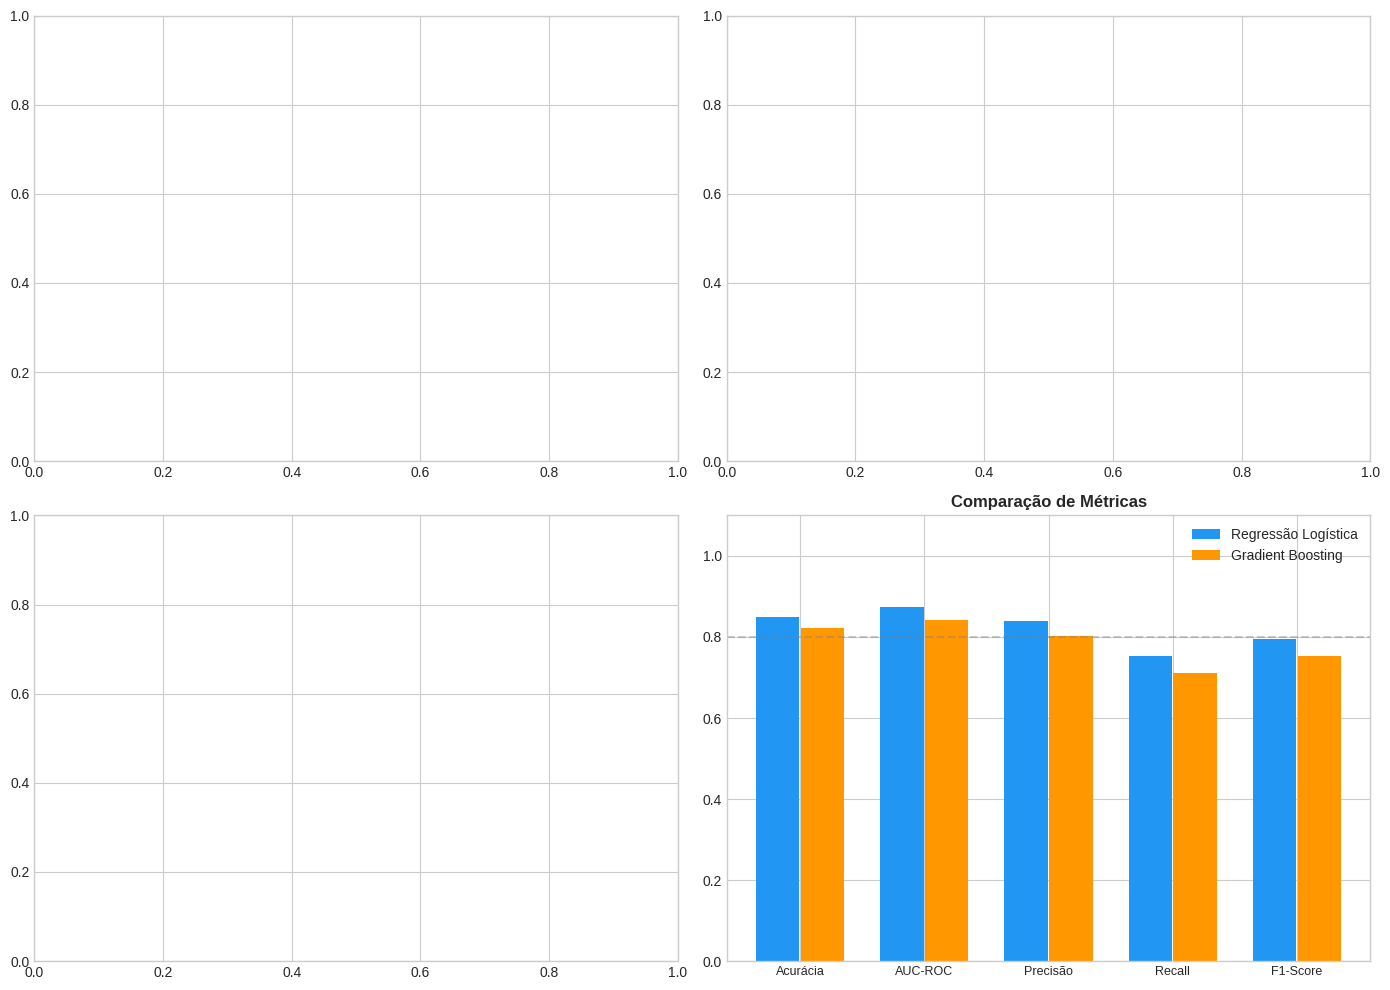

In [134]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = np.array(axes)

ax4 = axes[1][1]

metricas = ['Acurácia', 'AUC-ROC', 'Precisão', 'Recall', 'F1-Score']
vals_lr = [acc_lr, auc_lr, prec_lr, rec_lr, f1_lr]
vals_gb = [acc_gb, auc_gb, prec_gb, rec_gb, f1_gb]

x = np.arange(len(metricas))

ax4.bar(x - 0.18, vals_lr, 0.35, label='Regressão Logística', color='#2196F3')
ax4.bar(x + 0.18, vals_gb, 0.35, label='Gradient Boosting', color='#FF9800')

ax4.set_xticks(x)
ax4.set_xticklabels(metricas, fontsize=9)

ax4.set_ylim(0, 1.1)

ax4.set_title('Comparação de Métricas', fontweight='bold')
ax4.legend()

ax4.axhline(y=0.80, color='gray', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('comparacao_modelos.png', dpi=150, bbox_inches='tight')
plt.show()